<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part II: CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 8: $Z$ and $J/\psi$ Resonance Comparison
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Datasets derived from the Run2011A SingleElectron, SingleMu, DoubleElectron, and DoubleMu primary datasets</i>.
            <code>Jpsimumu.csv</code>. McCauley, T. Recorded 2011. Published 2017.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.x, Pandas, Matplotlib, NumPy, Pathlib, SciPy, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

The previous notebooks established the reconstruction and detailed characterisation of the $Z \rightarrow \mu^+\mu^-$ resonance using the simplified CMS Open Data sample. The final stage of the analysis extends this reconstruction to a substantially lighter jpsi resonance: the $J/\psi$ meson. The $J/\psi$ meson provides a useful comparison because both particles decay into an oppositely charged jpsi final state, allowing the same basic invariant-mass reconstruction procedure to be applied while probing a very different physical mass scale.

This notebook therefore compares the reconstructed $Z$ and $J/\psi$ resonances in terms of their event kinematics, invariant-mass spectra, fitted resonance parameters and overall physical characteristics. The comparison demonstrates how the same experimental observable, the invariant mass of a pair of reconstructed muons, can be used to identify resonances spanning more than an order of magnitude in mass.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utilities import (
    KINEMATIC_COLUMNS,
    ADDITIONAL_COLUMNS,
    TABLE_STYLES,
    make_formatter,
    dataset_summary,
    dataset_information,
    dataset_dimensions,
    event_statistics,
    multiple_dicts_to_summary_df
)

from src.particles import *

from src.validation import (
    analyse_residuals,
    residual_analysis_summary,
    transverse_momentum_calculation,
    total_momentum_calculation,
    anamolous_events_validation
)

from src.plotting import (
    set_plot_style,
    histogram_peak,
    histogram_bin_centers,
    plot_histogram,
    plot_overlay_histogram,
    histogram_panel_comparison
)

from src.fourvectors import invariant_mass_fourvector

from src.fit_peaks import(
    gaussian_peak,
    gaussian_fwhm,
    breit_wigner_peak,
    breit_wigner_fwhm,
    voigt_peak,
    voigt_fwhm,
    voigt_fwhm_error,
    initial_parameter_guess,
    popt_and_pcov,
    fit_statistics
)

set_plot_style()  # sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

In [2]:
#Load Dataset
jpsi = pd.read_csv("../../data/raw/cms_full/Jpsimumu.csv")
z_selected = pd.read_csv("../../data/processed/z_dimuon_part_2_selected.csv")

# GeV
JPSI_MASS_MIN = 2
JPSI_MASS_MAX = 5

## 2. &nbsp; Dataset Overview

Similar to the Double-muon, full CMS dataset, the $J/\psi$ data was also obtained from the CMS Open Data programme, an initiative that provides public access to data recorded by the Compact Muon Solenoid (CMS) experiment at the Large Hadron Collider (LHC), in the form of a <code>.csv</code> file.

The $J/\psi$ sample contains reconstructed jpsi candidates analogous to those used for the $Z \rightarrow \mu^+\mu^-$ analysis. The dataset provides the reconstructed kinematic quantities of the two muons, including their transverse momenta, pseudorapidities, azimuthal angles, energies and charges. These quantities are sufficient to reconstruct the jpsi invariant mass using the same four-vector formalism established earlier in the project.

Unlike the $Z$-boson sample, the $J/\psi$ resonance occurs at a much lower invariant mass of approximately $3.1\,\text{GeV}$ [1]. Consequently, its decay muons occupy a substantially softer kinematic regime. This difference is important when comparing the two samples, since selection requirements suitable for the high-mass $Z$-boson resonance cannot automatically be applied to the $J/\psi$ sample without removing a large fraction of its signal.

### 2.1 &nbsp; Dataset Semantics
The dataset is of the following structure:

<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            margin: 15px auto 25px auto; 
            max-width: 800px;
            border-left: 5px solid #165683; 
            padding: 8px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05);
            text-align:center;">
    <h3 style="color: #333; margin-bottom: 12px; font-size:15px; text-align:left">Table 1: Dataset Variable Dictionary</h3>
    <table style="border-collapse: collapse; width: 100%; box-shadow: 0 2px 5px rgba(0,0,0,0.05); border-radius: 4px; overflow: hidden; text-align:left;">
        <thead>
            <tr style="background-color: #343a40; color: white; text-align: left;">
                <th style="padding: 12px; font-size: 14px; width: 120px;">Variable</th>
                <th style="padding: 12px; font-size: 14px; width: 100px;">Unit / Type</th>
                <th style="padding: 12px; font-size: 14px;">Description</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Run</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The run number of the event.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Event</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The event number.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">type</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">string (G/T)</td>
                <td style="padding: 10px 12px; color: #495057;">Either T or G: whether the muon is a tracker (T) or global (G) muon.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">E, px, py, pz</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The total energy and components of the momemtum of the muon</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">pt</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The transverse momentum ($p_T$) of the muon.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">eta</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Float</td>
                <td style="padding: 10px 12px; color: #495057;">The pseudorapidity ($\eta$) of the muon.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">phi</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">rad</td>
                <td style="padding: 10px 12px; color: #495057;">The azimuthal angle ($\phi$) of the muon.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Q</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">&plusmn;1</td>
                <td style="padding: 10px 12px; color: #495057;">The electric charge of the muon.</td>
            </tr>
        </tbody>
    </table>
</div>

The above sturcture is presented twice for the two muons, with the suffix of 1 or 2 denoting the first or the second muon's properties respectively.

#### Definitions
- **Event**:  An event is a collision of particles occuring in the detector. In LHC, it is primarily a collision of protons.
- **Muon**: An elementary particle belonging to the second generation of leptons, with an electric charge of -1. It has properties similar to those of an electron, but it is about 200 times more masssive.
- **Meson**: A type of hadronic subatomic particle composed of an equal number of quarks and antiquarks, usually one of each, bound together by the strong interaction.
- **$J/\psi$** : A subatomic particle; a flavor-neutral meson consisting of a charm quark and a charm antiquark. 
- **Anti-Muon**: The anti-particle of Muon with an electric charge of +1.
- **Pseudorapidity**: The pseudorapidity $(\eta)$ is a coordinate that describes the angle of a particle produced in an event relative to the beam axis. $\eta = 0$ denotes that the produced particle is perpendicular to the beam axis.
- **Azimuthal Angle**: The azimuthal angle $(\phi)$ is the angle measured around the beam pipe (commonly the $z$-axis) in the transverse plane. In this case it ranges from $- \pi$ to $\pi$ angle.


### 2.2 &nbsp; Data Selection Procedure
For the double muon $J/\psi \rightarrow \mu^+\mu^-$ dataset, an event was selected if there were two muons in the event with $|\eta| < 2.4$, at least one muon was a global muon, the invariant mass of the two muons was in the range of $2 \,\text{GeV}$ to $5 \,\text{GeV}$, and they have opposite-sign charge.

### 2.3 &nbsp; Dataset Inspection

In [3]:
(jpsi.head()
    .rename(index=lambda x: x + 1)
    .style.set_caption(r"<b>Table 2:</b> First five events of the full $J/\psi$ jpsi dataset.")
    .set_table_styles(TABLE_STYLES)
)

,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
1,165617,75206813,G,10.162300,0.476300,-8.516400,5.523100,8.529700,0.609100,-1.514900,-1,G,19.775400,2.750800,-13.987100,13.705900,14.255000,0.853900,-1.376600,1
2,165617,75678475,G,15.879900,15.061800,-1.665800,-4.746400,15.153600,-0.308300,-0.110200,1,G,11.933800,11.908400,-0.767000,-0.085100,11.933000,-0.007100,-0.064300,-1
3,165617,74428554,G,21.827900,-6.221400,11.084500,17.744700,12.711100,1.135700,2.082300,-1,G,36.651300,-10.687400,15.069200,31.654400,18.474300,1.307600,2.187700,1
4,165617,75193169,G,19.492300,2.761200,-5.576900,-18.471900,6.223000,-1.808400,-1.111100,1,G,14.933400,1.552500,-6.125400,-13.530200,6.319000,-1.505000,-1.322600,-1
5,165617,74832715,G,8.097200,4.612700,-1.838900,6.394900,4.965700,1.071000,-0.379300,-1,T,3.513100,-0.530500,0.688000,3.402400,0.868800,2.074200,2.227600,1


In [4]:
(dataset_information(jpsi)
    .style.set_caption(r"<b>Table 3:</b> Data Types for full $J/\psi$ jpsi dataset")
    .set_table_styles(TABLE_STYLES)
)

,Data Type,Non-Null Entries
Run,int64,20000
Event,int64,20000
type1,str,20000
E1,float64,20000
px1,float64,20000
py1,float64,20000
pz1,float64,20000
pt1,float64,20000
eta1,float64,20000
phi1,float64,20000


The dataset information confirms that all variables have been imported successfully with appropriate numerical data types. The majority of the columns are stored as floating-point values, reflecting the continuous nature of the measured kinematic quantities, while the run number, event number, and particle charges are represented as integers, and the types are stored as strings. The absence of unexpected data types indicates that the dataset has been read correctly and is suitable for numerical analysis.

### 2.4 &nbsp; Dataset Descriptive Statistics

In [5]:
(dataset_summary(
    jpsi,
    ADDITIONAL_COLUMNS[0:2] + KINEMATIC_COLUMNS  # Removes the requirement for the M column
)
    .style.set_caption("<b>Table 4:</b> Dataset Descriptions")
    .set_table_styles(TABLE_STYLES)
)

,Mean,Standard Deviation,Minimum,Maximum
E1,16.257000,11.799000,2.780000,249.377000
E2,14.479000,10.956000,2.634000,228.986000
pt1,9.381000,6.413000,0.960000,231.431000
pt2,9.073000,6.408000,0.683000,223.435000
eta1,-0.001000,1.228000,-2.398000,2.400000
eta2,-0.001000,1.145000,-2.399000,2.398000
phi1,-0.011000,1.819000,-3.141000,3.141000
phi2,0.027000,1.821000,-3.141000,3.141000
Q1,0.185000,0.983000,-1.000000,1.000000
Q2,-0.185000,0.983000,-1.000000,1.000000


As described similarly in section 3.2 of notebook 5, the dataset statistics match the expections of this sample, and are fit for further numerical analysis.

### 2.5 &nbsp; Event Identifiers

In [6]:
event_statistics(jpsi)

duplicate_events = (
    jpsi[jpsi.duplicated(subset=["Event"], keep=False)]
    [["Run", "Event"]]
    .sort_values(["Event", "Run"])
)

print("\n")  # Blank lines for spacing

print(f"Duplicate rows: {jpsi.duplicated().sum()}")

duplicates = jpsi.duplicated(subset=["Run", "Event"]).sum()

print("Duplicate (Run, Event) pairs:", duplicates)

print("\n")  # Blank lines for spacing

summary = (
    duplicate_events
    .groupby("Event")["Run"]
    .apply(list)
    .reset_index(name="Runs")
    .rename(index=lambda x: x + 1)
    .style.set_caption("<b>Table 5:</b> Repeated Event Number(s)")
    .set_table_styles(TABLE_STYLES)
)

display(summary)

Total Events   : 20,000
Variables      : 20
Unique Runs    : 17
Unique Events  : 19999


Duplicate rows: 0
Duplicate (Run, Event) pairs: 0




,Event,Runs
1,17682966,"[160957, 163589]"


Although the dataset contains 20,000 rows and only 19,999 unique event numbers, this does not indicate a duplicated collision event. In CMS data, an event is uniquely identified by the combination of its run number and event number. Examination of the (Run, Event) pairs, and the fact that there are no duplicate rows as shown above, confirm that each collision event is represented only once within the dataset, with the repeated event numbers occurring for event number 17682966, with corresponding run numbers 160957 and 163589.

## 3. &nbsp; $J/\psi$ Events Validation and Selection

### 3.1 &nbsp; $J/\psi$ Transverse Momentum Validation

,Muon,Mean Residual,Std. Dev.,Max. Abs. Difference,Difference Limits
1,Muon 1,-0.0087,1.5359,215.628,"(-215.628, 7.186)"
2,Muon 2,7.052e-06,1.133,119.788,"(-119.788, 98.364)"


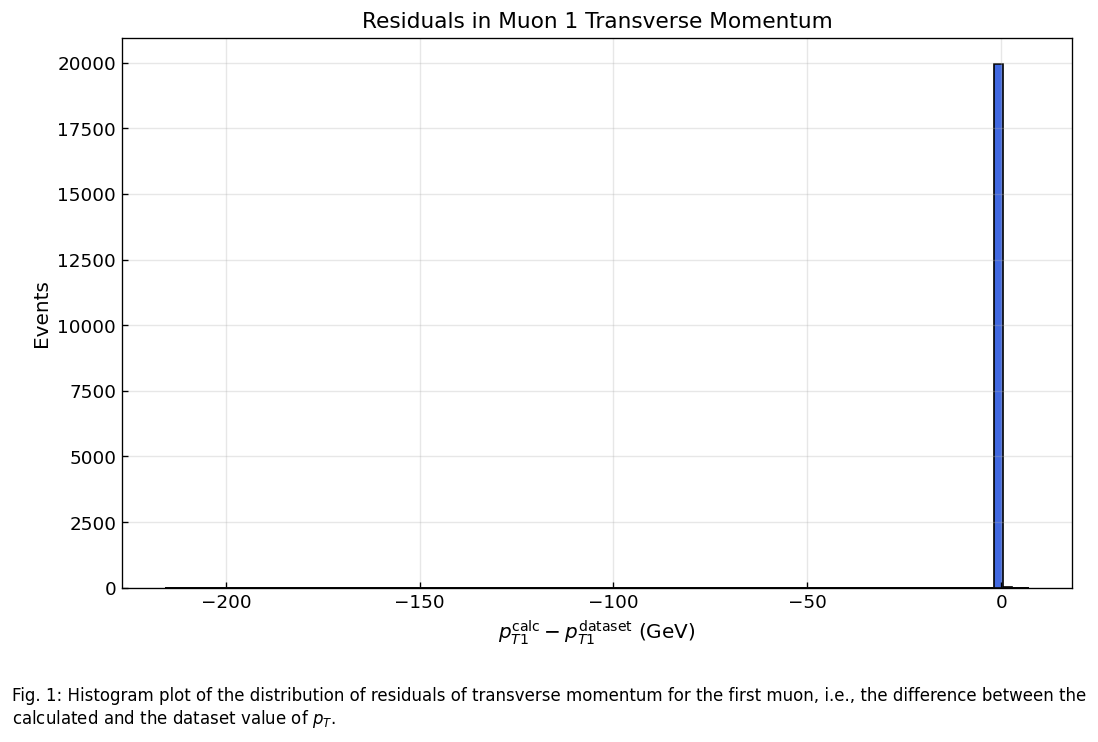

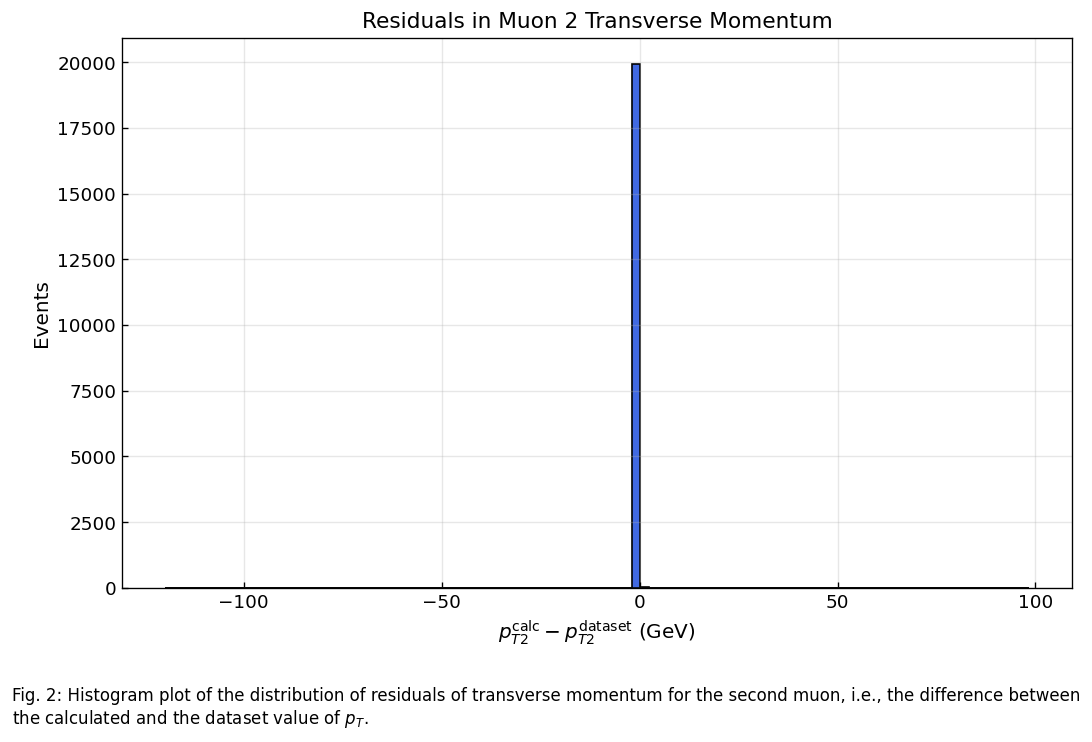

In [7]:
pt1_calc = transverse_momentum_calculation(jpsi["px1"], jpsi["py1"])
pt2_calc = transverse_momentum_calculation(jpsi["px2"], jpsi["py2"])

pt1_residual = pt1_calc - jpsi["pt1"]
pt2_residual = pt2_calc - jpsi["pt2"]

pt_comparison_1 = analyse_residuals(pt1_residual)
pt_comparison_2 = analyse_residuals(pt2_residual)


pt_diff_summary = residual_analysis_summary(pt_comparison_1,
                                            pt_comparison_2,
                                            caption="<b>Table 6:</b> Transverse Momentum Validation")

display(pt_diff_summary)


plot_histogram(
    pt1_residual,
    bins=100,
    xlabel=r"$p_{T1}^{\text{calc}}-p_{T1}^{\text{dataset}}$ (GeV)",
    ylabel="Events",
    title="Residuals in Muon 1 Transverse Momentum",
    caption=r"Fig. 1: Histogram plot of the distribution of residuals of transverse momentum for the first muon, i.e., the difference between the calculated and the dataset value of $p_T$."
)

print() # Blank line for spacing

plot_histogram(
    pt2_residual,
    bins=100,
    xlabel=r"$p_{T2}^{\text{calc}}-p_{T2}^{\text{dataset}}$ (GeV)",
    ylabel="Events",
    title="Residuals in Muon 2 Transverse Momentum",
    caption=r"Fig. 2: Histogram plot of the distribution of residuals of transverse momentum for the second muon, i.e., the difference between the calculated and the dataset value of $p_T$."
)

For the overwhelming majority of events, the independently reconstructed transverse momenta agree closely with the supplied values, with residuals around 0. However, a small subset of events exhibits noticeably larger absolute residuals, as depicted in the plots above.

### 3.2. &nbsp; Investigation of Anomalous Events

In [8]:
summary_table, outliers_table = anamolous_events_validation(
    jpsi, 
    pt1_calc, 
    pt1_residual,
    summary_caption="<b>Table 7:</b> Summary of transverse momentum anomalies",
    outlier_table_caption="<b>Table 8:</b> The 10 largest transverse momentum discrepancies, sorted by absolute residuals."
)

display(summary_table)
print("\n")  # Blank lines for spacing
display(outliers_table)

Quantity,Value
Total events,20000
Events with |Residual| > 1 GeV,32
Percentage of dataset,0.160%


Run,Event,E1,px1,py1,pz1,pt1,Calculated pt,Residual,Relative Error (%)
166784,52198564,53.623,0.342,15.799,51.242,231.431,15.803,-215.628,93.17
163589,3105304,15.372,-7.052,9.481,-9.832,25.047,11.816,-13.231,52.82
166895,87180320,4.331,3.026,1.897,-2.448,13.520,3.571,-9.949,73.59
163589,5759841,3.417,-2.260,-2.560,-0.036,11.755,3.415,-8.340,70.95
173692,605305378,17.260,6.929,3.741,15.359,15.361,7.874,-7.487,48.74
165548,612476708,43.979,-28.745,-7.797,-32.359,22.598,29.784,7.186,31.80
163589,21910016,61.663,6.397,17.628,-58.742,12.303,18.753,6.451,52.43
166701,689676951,11.245,2.044,3.039,-10.632,9.368,3.663,-5.706,60.90
167807,1091909997,57.092,-4.430,-49.412,-28.254,44.875,49.610,4.735,10.55
163796,100767509,47.721,20.826,-22.547,-36.541,26.128,30.694,4.565,17.47


### 3.3. &nbsp; Event Selection

The $J/\psi$ sample requires a different event-selection strategy from the $Z$-boson sample because the two resonances occupy very different kinematic regimes. In particular, the transverse momenta of the $J/\psi$ decay muons are substantially lower than those characteristic of the selected $Z\rightarrow\mu^+\mu^-$ events. The high-$p_T$ requirements used for the $Z$ analysis would therefore remove a large fraction of genuine $J/\psi$ candidates and would not provide a meaningful comparison.

The initial selection requires the two reconstructed muons to have opposite electric charge, consistent with the expected $J/\psi\rightarrow\mu^+\mu^-$ decay. The invariant mass is then reconstructed using the validated dimuon procedure, after which a mass window centred on the observed $J/\psi$ resonance is applied. This approach avoids imposing unnecessarily restrictive kinematic requirements and allows the characteristic low-energy $J/\psi$ signal to remain visible.

Total events: 20000
Opposite-charge events: 20000



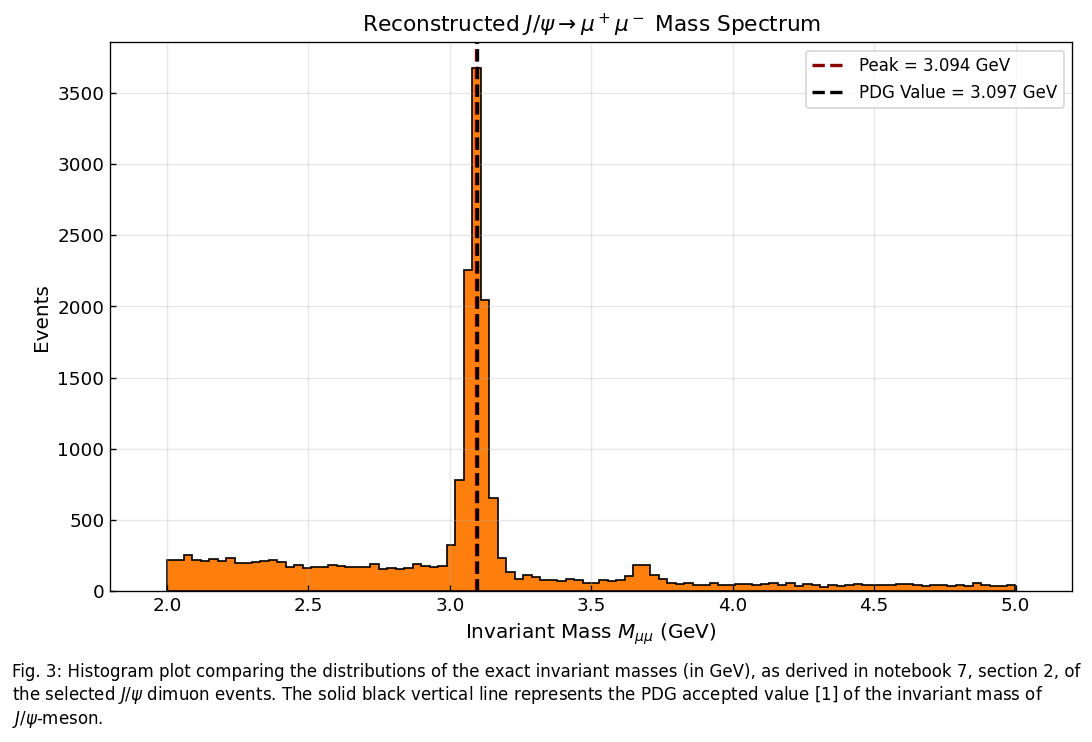

In [9]:
# Opposite charge pairs requirement

jpsi_opposite_charge = jpsi[
    jpsi["Q1"] * jpsi["Q2"] == -1
].copy()

print("Total events:", len(jpsi))
print("Opposite-charge events:", len(jpsi_opposite_charge))
print()  # Blank line


jpsi_opposite_charge["M_calc"] = invariant_mass_fourvector(jpsi_opposite_charge)

# Imposes 2-5 GeV hard limits
jpsi_selected = jpsi_opposite_charge[
    jpsi_opposite_charge["M_calc"].between(
        JPSI_MASS_MIN,
        JPSI_MASS_MAX
    )
].copy()

mass_histogram_peak = histogram_peak(jpsi_selected["M_calc"])

plot_histogram(
    jpsi_selected["M_calc"],
    bins=100,
    xlabel=r"Invariant Mass $M_{\mu\mu}$ (GeV)",
    ylabel="Events",
    title=r"Reconstructed $J/\psi \rightarrow \mu^+\mu^-$ Mass Spectrum",
    color="#ff7f0e",
    vlines=[
        (mass_histogram_peak, f"Peak = {mass_histogram_peak:.3f} GeV", "darkred"),
        (PDG_JPSI_MASS, f"PDG Value = {PDG_JPSI_MASS:.3f} GeV", "black")    
    ],
    xlimit=(1.8, 5.2),  # Mass window, with some visual margin
    caption=f"""Fig. 3: Histogram plot comparing the distributions of the exact invariant masses (in GeV), as derived in notebook 7, section 2, of the selected $J/\\psi$ dimuon events.\
 The solid black vertical line represents the PDG accepted value [1] of the invariant mass of $J/\\psi$-meson.""",
    save_path="../../figures/jpsi_mumu_mass_spectrum_part_2.png",
    alt_caption=f"""Histogram plot comparing the distributions of the exact invariant masses (in GeV), as derived in notebook 7, section 2, of the selected $J/\\psi$ dimuon events.\
 The solid dark red line represents the peak of the reconstructed $J/\\psi$-meson mass spectrum.\
 The solid black vertical line represents the PDG accepted value, {PDG_JPSI_MASS:.3f} GeV, of the invariant mass of $J/\\psi$-meson."""
)

The invariant mass of each selected dimuon candidate is reconstructed using the same exact four-vector calculation established and independently validated in the earlier notebooks. No new reconstruction method is introduced here; the purpose is instead to determine whether the previously validated procedure successfully identifies the substantially lower-mass $J/\psi$ resonance.

The resulting invariant-mass distribution has a histogram peak at approximately $3.094\,\text{GeV}$, in close agreement with the Particle Data Group (PDG) value of approximately $3.097\,\text{GeV}$ [1]. The difference of about $0.003\,\text{GeV}$ is small and may arise from the finite histogram bin width, statistical fluctuations and detector or reconstruction effects. This agreement provides an independent demonstration that the invariant-mass technique used for the $Z$-boson is applicable across substantially different energy scales and is capable of identifying both electroweak and quarkonium resonances from their common dimuon final state.

## 4. &nbsp; Comparison of Kinematic Distributions

### 4.1 &nbsp; Comparison of Muon Transverse Momenta

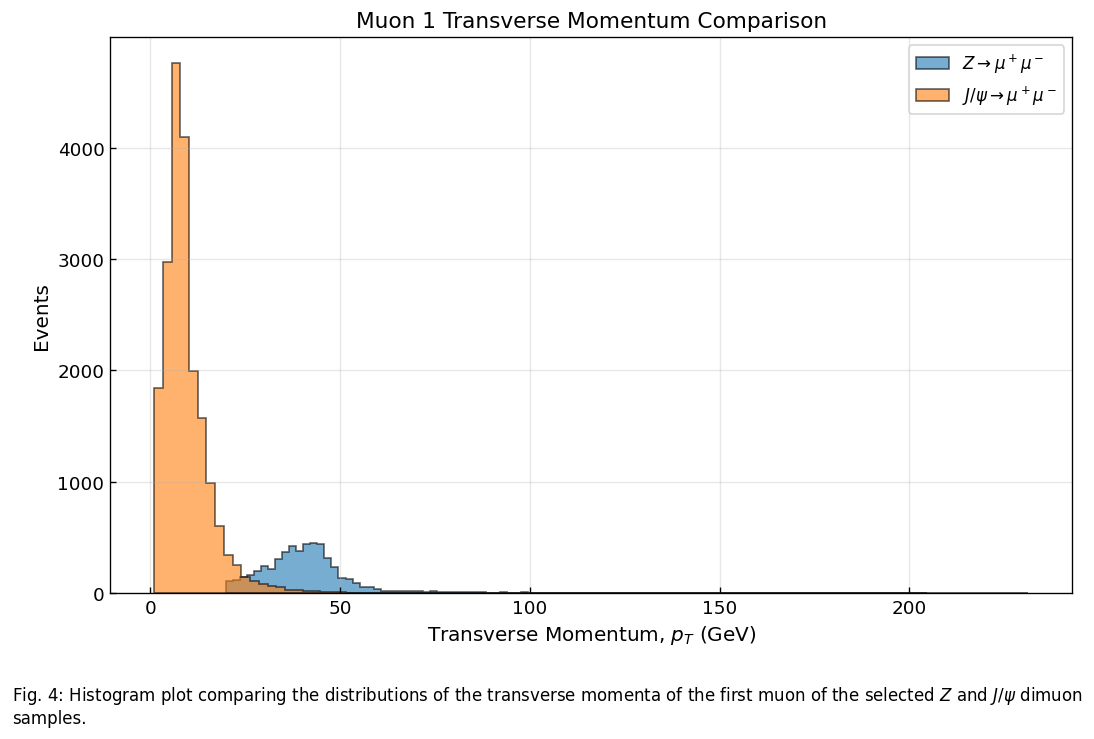

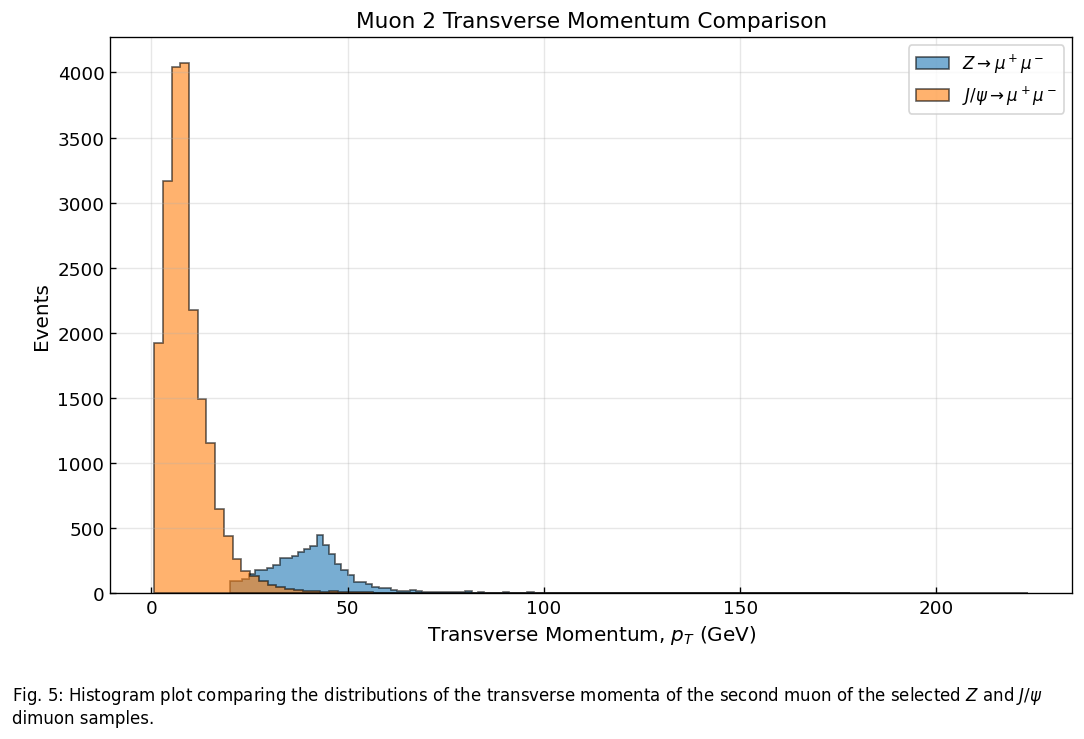

In [10]:
# Muon 1
plot_overlay_histogram(
    z_selected["pt1"],
    jpsi_selected["pt1"],
    bins=100,
    xlabel=r"Transverse Momentum, $p_T$ (GeV)",
    ylabel="Events",
    title="Muon 1 Transverse Momentum Comparison",
    colors=("#1f77b4", "#ff7f0e"),
    label1=r"$Z \rightarrow \mu^+\mu^-$",
    label2=r"$J/\psi \rightarrow \mu^+\mu^-$",
    caption="Fig. 4: Histogram plot comparing the distributions of the transverse momenta of the first muon of the selected $Z$ and $J/\\psi$ dimuon samples.",
    save_path="../../figures/jpsi_z_mumu_pt_comparison_part_2.png",
    alt_caption="Histogram plot comparing the distributions of the transverse momenta of the first muon of the selected $Z$ and $J/\\psi$ dimuon samples."
)

print("\n")  # Blank lines for spacing

# Muon 2
plot_overlay_histogram(
    z_selected["pt2"],
    jpsi_selected["pt2"],
    bins=100,
    xlabel=r"Transverse Momentum, $p_T$ (GeV)",
    ylabel="Events",
    title="Muon 2 Transverse Momentum Comparison",
    colors=("#1f77b4", "#ff7f0e"),
    label1=r"$Z \rightarrow \mu^+\mu^-$",
    label2=r"$J/\psi \rightarrow \mu^+\mu^-$",
    caption="Fig. 5: Histogram plot comparing the distributions of the transverse momenta of the second muon of the selected $Z$ and $J/\\psi$ dimuon samples."
)

The kinematic distributions provide a direct illustration of the large difference in energy scale between the two resonances. The muons produced in the $Z$-boson sample generally possess substantially larger transverse momenta and energies than those in the $J/\psi$ sample. This difference follows naturally from the much larger mass of the $Z$-boson and the very different production and decay kinematics of the two systems.

The $J/\psi$ sample is consequently concentrated at much lower muon transverse momenta, whereas the $Z$-boson sample extends to considerably higher values and exhibits a more pronounced high-energy tail. The comparison demonstrates why the event-selection criteria cannot simply be transferred unchanged between the two analyses. This behaviour is consistent across both the first and the second muon candidates.

### 4.2 &nbsp; Comparison of Energies

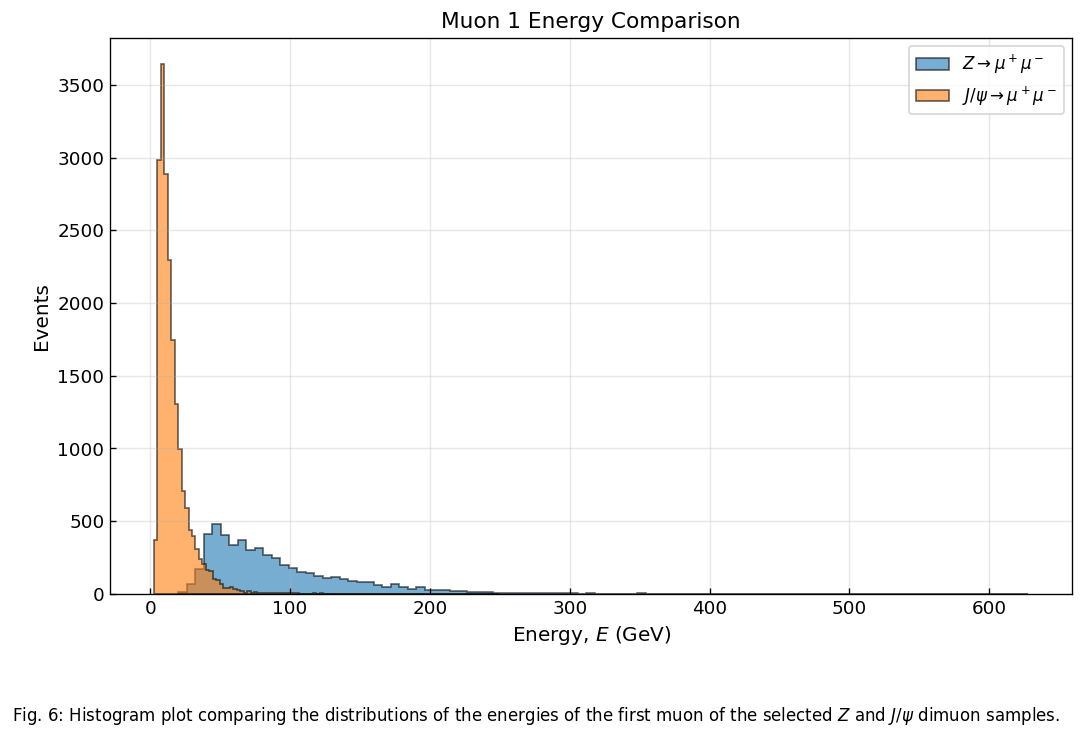

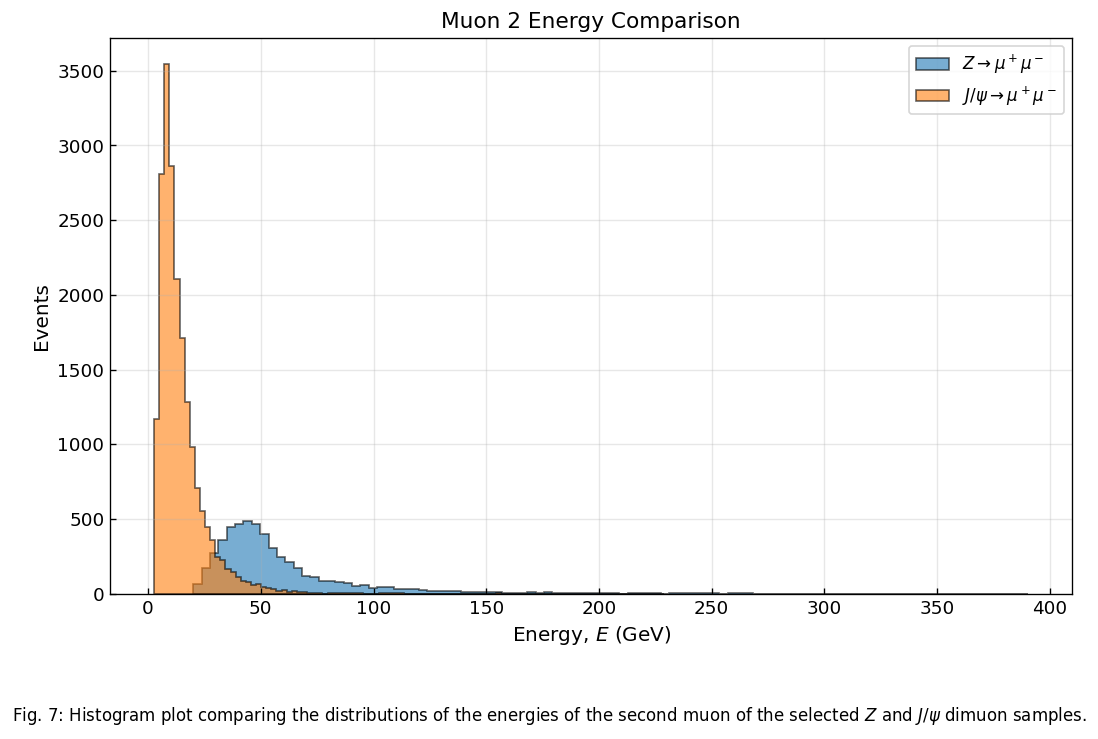

In [11]:
# Muon 1
plot_overlay_histogram(
    z_selected["E1"],
    jpsi_selected["E1"],
    bins=100,
    xlabel=r"Energy, $E$ (GeV)",
    ylabel="Events",
    title="Muon 1 Energy Comparison",
    colors=("#1f77b4", "#ff7f0e"),
    label1=r"$Z \rightarrow \mu^+\mu^-$",
    label2=r"$J/\psi \rightarrow \mu^+\mu^-$",
    caption="Fig. 6: Histogram plot comparing the distributions of the energies of the first muon of the selected $Z$ and $J/\\psi$ dimuon samples.",
    save_path="../../figures/jpsi_z_mumu_energy_comparison_part_2.png",
    alt_caption="Histogram plot comparing the distributions of the energies of the first muon of the selected $Z$ and $J/\\psi$ dimuon samples."
)

print("\n")  # Blank lines for spacing

# Muon 2
plot_overlay_histogram(
    z_selected["E2"],
    jpsi_selected["E2"],
    bins=100,
    xlabel=r"Energy, $E$ (GeV)",
    ylabel="Events",
    title="Muon 2 Energy Comparison",
    colors=("#1f77b4", "#ff7f0e"),
    label1=r"$Z \rightarrow \mu^+\mu^-$",
    label2=r"$J/\psi \rightarrow \mu^+\mu^-$",
    caption="Fig. 7: Histogram plot comparing the distributions of the energies of the second muon of the selected $Z$ and $J/\\psi$ dimuon samples."
)

For both the transverse momentum and the energy distributions, it is evident that while the $Z \rightarrow \mu^+\mu^-$ dimuon events have larger values, the $J/\psi \rightarrow \mu^+\mu^-$ dimuon events have a narrower tail, and more concentrated near the peak of the distribution, thereby providing it with a considerably larger number of events near the peak region. This behaviour is consistent across both the first and the second muon candidates.

### 4.3 &nbsp; Comparison Statistics

In [12]:
kinematic_variables_z_boson = {
    r"Muon 1 $p_{T1}$": z_selected["pt1"].mean(),
    r"Muon 2 $p_{T2}$": z_selected["pt2"].mean(),
    r"Muon 1 Energy": z_selected["E1"].mean(),
    r"Muon 2 Energy": z_selected["E2"].mean()
}

kinematic_variables_j_psi_meson = {
    r"Muon 1 $p_{T1}$": jpsi_selected["pt1"].mean(),
    r"Muon 2 $p_{T2}$": jpsi_selected["pt2"].mean(),
    r"Muon 1 Energy": jpsi_selected["E1"].mean(),
    r"Muon 2 Energy": jpsi_selected["E2"].mean()
}


display(multiple_dicts_to_summary_df(
    {
        "Z Mean": kinematic_variables_z_boson,
        r"$J/\psi$ Mean": kinematic_variables_j_psi_meson
    },
    metric_col="Quantity (GeV)",
    caption=r"<b>Table 9: </b> Comparison of kinematic distribution statistics."
    )
)

Quantity (GeV),Z Mean,$J/\psi$ Mean
Muon 1 $p_{T1}$,40.75,9.38
Muon 2 $p_{T2}$,40.67,9.07
Muon 1 Energy,89.87,16.26
Muon 2 Energy,59.06,14.47


The larger difference between the two $Z$-muon energies also indicates that the individual decay muons can carry substantially different energies in the laboratory frame, depending on the boost and decay kinematics of the parent $Z$-boson. In contrast, the $J/\psi$ muons occupy a much narrower and lower-energy range. Overall, the comparison demonstrates that the same dimuon final state can arise at very different energy scales, with the reconstructed kinematics reflecting the substantially different masses and production dynamics of the two resonances.

## 5. &nbsp; Comparison of Resonance Spectra

### 5.1 &nbsp; Comparison of Invariant Mass Spectra

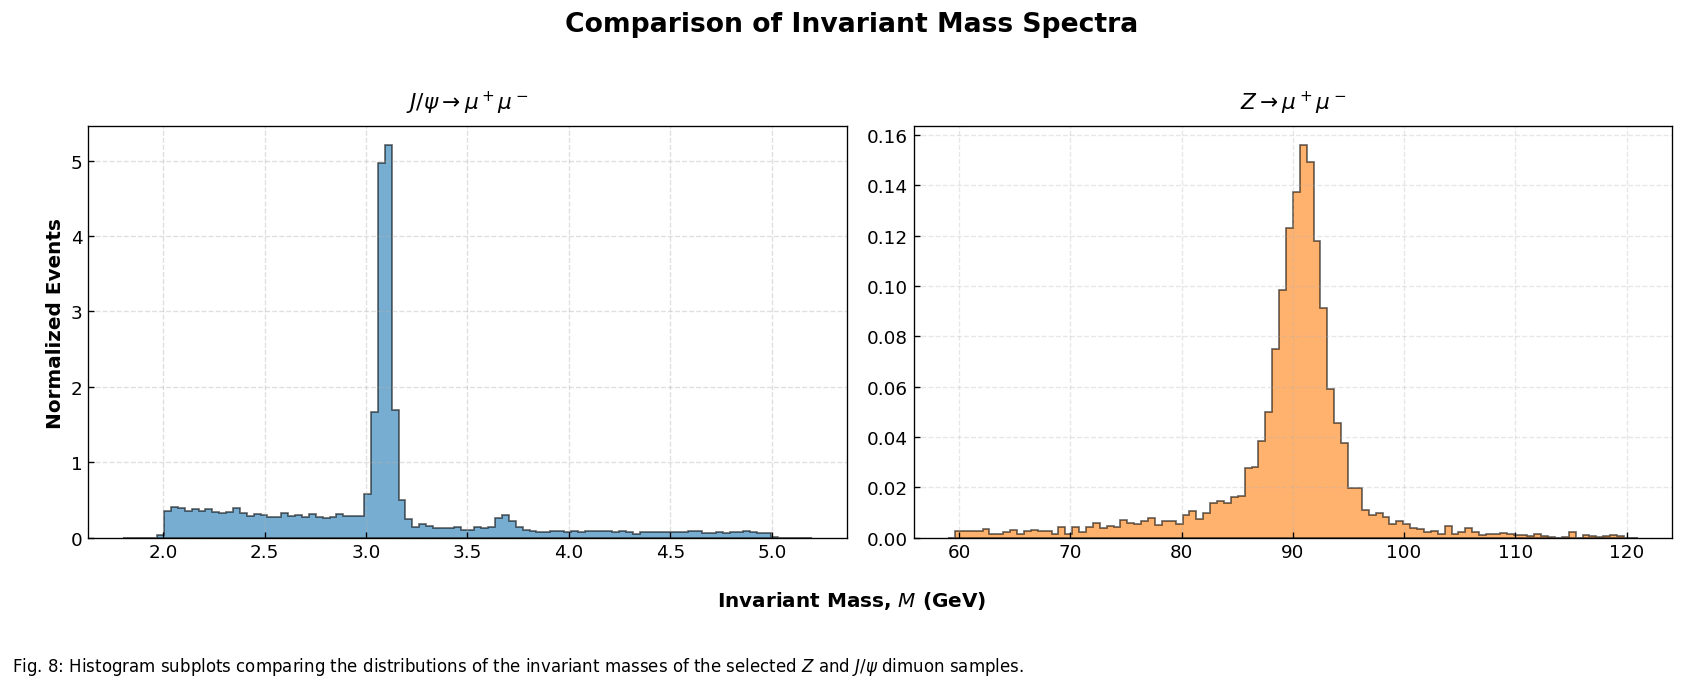

Figure saved at: figures/../../figures/jpsi_z_mumu_inv_mass_spectra_comparison_part_2.png


In [13]:
z_selected_mass=invariant_mass_fourvector(z_selected)

histogram_panel_comparison(
    jpsi_selected["M_calc"],
    z_selected_mass,
    title_1=r"$J/\psi \rightarrow \mu^+\mu^-$",
    title_2=r"$Z \rightarrow \mu^+\mu^-$",
    suptitle="Comparison of Invariant Mass Spectra",
    x_label=r"Invariant Mass, $M$ (GeV)", 
    y_label="Normalized Events",
    caption=r"Fig. 8: Histogram subplots comparing the distributions of the invariant masses of the selected $Z$ and $J/\psi$ dimuon samples.",
    save_path="../../figures/jpsi_z_mumu_inv_mass_spectra_comparison_part_2.png",
    alt_caption="""Histogram plot comparing the distributions of the energies of the first muon of the selected $Z$ and $J/\\psi$ dimuon samples on a normalised probability density scale.\
 The $J/\\psi$ distribution is depicted in royalblue, and the $Z$ distribution in orange.
"""
)

Normalizing to probability density allows direct comparisons of spectral shapes and detector resolution across completely different mass scales and sample sizes. From the plots, it is evident that for a narrow resonance spectrum like $J/\psi$, events are tightly clustered, therefore forcing the height of the peak to reach close to $5 \, \text{GeV}^{-1}$ on the normalised scale, to conserve the unitary area. Conversely, the broad $Z$-boson peak has its probability density spread across a much wider region, resulting in a significant lower peak height.

Despite the difference in mass scale, both spectra exhibit the characteristic behaviour expected of resonant particle production: an enhancement in the event rate around a well-defined invariant mass. The comparison therefore provides a particularly clear demonstration of how resonance identification is performed experimentally. The same basic observable and reconstruction procedure reveal physically distinct states without requiring knowledge of the identity of the parent particle beforehand.

### 5.2 &nbsp; Resonance Mass and Width Comparison

The peak fitting process described in detail in notebook 7, section 3, is utilised here. The definitions and derivations are not repeated for brevity. The Gaussian, Breit-Wigner and Voigt profiles are fitted to the $J/\psi$ dimuon sample data and visualised for analysis.

In [14]:
bin_counts, bin_centres = histogram_bin_centers(jpsi_selected["M_calc"], bins=100)

# Peak region
fit_mask = (
    (bin_centres >= 2.5) &
    (bin_centres <= 3.5)
)

x_fit = bin_centres[fit_mask]
y_fit = bin_counts[fit_mask]

y_error = np.sqrt(np.maximum(y_fit, 1))  # Sigma_i values

# Optional parameters and errors for Gaussian fit

p0_gaussian = list(initial_parameter_guess(x_fit, y_fit)["gaussian"].values())

gaussian_curve_fit_data = popt_and_pcov(
    gaussian_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_gaussian
)

# Optional parameters and errors for Breit-Wigner fit

p0_breit_wigner = list(initial_parameter_guess(x_fit, y_fit)["breit_wigner"].values())

breit_wigner_curve_fit_data = popt_and_pcov(
    breit_wigner_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_breit_wigner
)

# Optional parameters and errors for Voigt fit

p0_voigt = list(initial_parameter_guess(x_fit, y_fit)["voigt"].values())

voigt_curve_fit_data = popt_and_pcov(
    voigt_peak,
    x_fit,
    y_fit,
    y_error,
    initial_guess=p0_voigt
)

### 5.3 &nbsp; Model Fit Statistics Comparison

In [15]:
# FWHM Values added to the combined dictionaries

fit_formatter = make_formatter(decimals=3)  # Formatting instance

gaussian_fit_statistics = fit_statistics(
    gaussian_peak,
    x_fit,
    y_fit,
    y_error,
    gaussian_curve_fit_data[0]
)

gaussian_popt = gaussian_curve_fit_data[0]
gaussian_pcov = gaussian_curve_fit_data[1]

gaussian_sigma = gaussian_popt[2]
gaussian_sigma_error = np.sqrt(gaussian_pcov[2, 2])

gaussian_fwhm_val, gaussian_fwhm_err = gaussian_fwhm(gaussian_sigma, gaussian_sigma_error)
gaussian_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(gaussian_fwhm_val)} ± {fit_formatter(gaussian_fwhm_err)}"
gaussian_fit_statistics["Relative Width"] = fit_formatter(gaussian_fwhm_val / PDG_JPSI_MASS)

                                   
breit_wigner_fit_statistics = fit_statistics(
    breit_wigner_peak,
    x_fit,
    y_fit,
    y_error,
    breit_wigner_curve_fit_data[0]
)

breit_wigner_popt = breit_wigner_curve_fit_data[0]
breit_wigner_pcov = breit_wigner_curve_fit_data[1]

breit_wigner_gamma = breit_wigner_popt[2]
breit_wigner_gamma_error = np.sqrt(breit_wigner_pcov[2, 2])

breit_wigner_fwhm_val, breit_wigner_fwhm_err = breit_wigner_fwhm(breit_wigner_gamma, breit_wigner_gamma_error)
breit_wigner_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(breit_wigner_fwhm_val)} ± {fit_formatter(breit_wigner_fwhm_err)}"
breit_wigner_fit_statistics["Relative Width"] = fit_formatter(breit_wigner_fwhm_val / PDG_JPSI_MASS)


voigt_fit_statistics = fit_statistics(
    voigt_peak,
    x_fit,
    y_fit,
    y_error,
    voigt_curve_fit_data[0]
)

voigt_popt = voigt_curve_fit_data[0]
voigt_pcov = voigt_curve_fit_data[1]

voigt_sigma = voigt_popt[2]
voigt_gamma = voigt_popt[3]

voigt_fit_statistics["FWHM (GeV)"] = f"{fit_formatter(voigt_fwhm(voigt_sigma, voigt_gamma))} ± {fit_formatter(voigt_fwhm_error(voigt_sigma, voigt_gamma, voigt_pcov))}"
voigt_fit_statistics["Relative Width"] = fit_formatter(voigt_fwhm(voigt_sigma, voigt_gamma) / PDG_JPSI_MASS)


# Display comparison summary
comparison_table_row_keys = [
    "FWHM (GeV)",
    "Relative Width",
    "Chi-squared",
    "Degrees of Freedom",
    "Reduced Chi-squared",
    "p-value",
    "AIC",
    "BIC"
]

model_comparisons=multiple_dicts_to_summary_df(
    data_dicts={
        "Gaussian": gaussian_fit_statistics,
        "Breit-Wigner": breit_wigner_fit_statistics,
        "Voigt": voigt_fit_statistics
    },
    metric_col="Metric",
    keys_list=comparison_table_row_keys,
    caption=r"<b>Table 10:</b> Comparison Table of the Models for $J/\psi$-meson"
)

display(model_comparisons)

model_comparisons.data.to_csv(
    "../../data/processed/jpsi_dimuon_part_2_fit_summary.csv",
    index=False
)  # Save the statistics

Metric,Gaussian,Breit-Wigner,Voigt
FWHM (GeV),0.077 ± 7.611e-04,0.051 ± 8.091e-04,0.072 ± 0.001
Relative Width,0.025,0.016,0.023
Chi-squared,136.29,504.14,59.02
Degrees of Freedom,28,28,27
Reduced Chi-squared,4.87,18.01,2.19
p-value,3.4e-16,9.4e-89,3.5e-04
AIC,146.29,514.14,71.02
BIC,153.77,521.63,80


The three peak models give substantially different descriptions of the reconstructed $J/\psi$ resonance. The Gaussian model provides a poor goodness of fit, with a reduced $\chi^2$ of $4.87$ and a very small $p$-value of $3.4\times10^{-16}$, indicating that the observed distribution is not adequately described by a simple Gaussian profile. The Breit-Wigner model performs considerably worse, with a reduced $\chi^2$ of $18.01$ and a $p$-value of $9.4\times10^{-89}$, providing strong evidence against this model as an appropriate description of the reconstructed peak.

The Voigt model provides the best description among the three models considered. It gives the lowest $\chi^2$, reduced $\chi^2$, AIC and BIC values, together with the largest $p$-value of $3.5\times10^{-4}$. Although this $p$-value is still below the conventional $0.05$ threshold, the Voigt profile is substantially more consistent with the observed distribution than either the Gaussian or Breit-Wigner models. Its reduced $\chi^2$ of $2.19$ also indicates that the fit is not statistically perfect, suggesting that the simplified model does not capture all features of the reconstructed $J/\psi$ spectrum, and is not statistically as good as the same for $Z$-boson.

The fitted FWHM values also differ between the models, with the Breit-Wigner profile producing the narrowest width and the Gaussian profile the broadest. However, these fitted widths should not be interpreted as direct measurements of the intrinsic $J/\psi$ decay width, since the observed resonance shape is affected by detector resolution, reconstruction effects, binning and the characteristics of the simplified dataset. The statistical comparison therefore provides stronger evidence for preferring the Voigt model than the numerical width alone. However, in comparison with the $Z$-boson FWHM values, the $J/\psi$ peak width is much narrower, reinforcing the previously established fact demonstrated in the invariant mass comparison study in section 5.1. The relative widths also being lower than those of $Z$-boson further strengthens this observation.

Overall, the model comparison indicates that the $J/\psi$ resonance has a reconstructed shape that cannot be adequately represented by a simple Gaussian or Breit-Wigner profile within this dataset. The Voigt profile gives the most satisfactory description of the available data, although the remaining discrepancy between the model and observations demonstrates the limitations of applying simple analytical peak functions to a reconstructed experimental resonance.

## 6. &nbsp; Physical Interpretation

The comparison between the two resonances illustrates the distinct physical origins of these particles despite their identical reconstructed final state ($\mu^+\mu^-$). The $Z$-boson is an elementary gauge boson mediating the neutral electroweak interaction, produced predominantly via quark-antiquark annihilation ($q\bar{q} \rightarrow Z$), also known as the Drell-Yan process [2]. Conversely, the $J/\psi$ is a neutral, bound state of a charm quark and charm antiquark ($c\bar{c}$) produced primarily through strong (QCD) processes. At hadron colliders it's dominated by gluon-gluon fusion (with contributions from color-singlet/color-octet mechanisms in NRQCD [3], plus feed-down from $\chi_c, \, \psi \, (2S)$ decays), rather than generic strong-force production. Both are spin-1 bosons that couple directly to fermion-antifermion currents, allowing their direct decay into oppositely charged muon pairs.

The $J/\psi \rightarrow \mu^+\mu^-$ decay proceeds via electromagnetic annihilation ($c\bar{c} \rightarrow \gamma^* \rightarrow \mu^+\mu^-$). Because gluons cannot couple to leptons, even though the $J/\psi$ is a QCD bound state, its leptonic decay is purely a QED process. This explains why the branching fraction to $\mu^+\mu^-$ is only $\approx 6\,\%$, competing directly against $\approx 88\,\%$ hadronic and gluonic decay modes [1]. In contrast, $Z \rightarrow \mu^+\mu^-$ proceeds via the direct weak neutral-current coupling, with a leptonic branching fraction of $\approx 3.37\,\%$ [4].

The $J/\psi$ resonance occurs at a much lower energy scale ($\approx 3.10\,\text{GeV}$) [1] and produces correspondingly softer decay muons than the $Z$-boson ($\approx 91.19\,\text{GeV}$) [4]. Intrinsically, the $J/\psi$ has an extremely narrow natural decay width ($\Gamma \approx 93\,\text{keV}$), meaning its observed peak width in data is almost entirely dictated by experimental detector resolution. In contrast, the $Z$-boson has a large natural width ($\Gamma \approx 2.49\,\text{GeV}$), making its reconstructed profile a convolution of both intrinsic lifetime dynamics and energy-dependent momentum smearing (which broadens at higher $p_T$). Consequently, fitted peak widths reflect the reconstructed resonance profile rather than a raw measurement of natural lifetime.

Ultimately, this comparison highlights the power of invariant-mass reconstruction as a universal experimental technique in high-energy physics. By selecting a single, clean final state of two oppositely charged muons, detector analyses can probe fundamentally different sectors of the Standard Model across several orders of magnitude in energy scale.

## 7. &nbsp; Project Summary and Conclusion

This project investigated the reconstruction and characterisation of particle resonances using simplified CMS Open Data, with particular emphasis on dimuon final states. The analysis began with an exploration of the reconstructed lepton observables and the structure of the available datasets, providing an understanding of the kinematic quantities used throughout the reconstruction. The theoretical basis of the analysis was then established through the derivation of the relativistic invariant-mass relation from four-vector kinematics.

The reconstruction procedure was initially applied to $Z\rightarrow\mu^+\mu^-$ events and subsequently compared with the corresponding $Z\rightarrow e^+e^-$ channel. Independent validation of the reconstructed transverse momentum, pseudorapidity, azimuthal angle and energy demonstrated that the relevant kinematic quantities could be reproduced consistently from the supplied measurements. The comparison between the exact lepton-mass treatment and the massless approximation further showed that the lepton rest-mass contribution is negligible at the energy scale of the $Z$-boson.

Event-selection criteria were then developed to isolate a clean $Z$-boson sample. Opposite-charge requirements, transverse-momentum thresholds, pseudorapidity acceptance and an invariant-mass window were applied sequentially, with the effect of each selection quantified through the corresponding event counts and efficiencies. The resulting sample produced a clear resonance centred close to the accepted $Z$-boson mass, demonstrating the successful reconstruction of the resonance from its decay products.

The $Z\rightarrow\mu^+\mu^-$ resonance was subsequently characterised using Gaussian, Breit-Wigner and Voigt models. Their descriptions of the observed spectrum were compared using chi-squared statistics, reduced chi-squared, goodness-of-fit $p$-values, AIC, BIC and residual analysis. The Voigt profile provided the strongest overall description of the reconstructed $Z$-boson peak among the models considered, illustrating the importance of accounting for both resonance broadening and detector resolution when describing an experimental mass spectrum.

Finally, the same validated reconstruction approach was applied to a $J/\psi\rightarrow\mu^+\mu^-$ sample. Despite the substantially different mass and kinematic scale, the invariant-mass calculation successfully produced a resonance near $3.1\,\text{GeV}$ [1]. Comparison of the $J/\psi$ and $Z$-boson samples demonstrated that the same experimental technique can identify physically distinct resonances from an identical dimuon final state, providing a direct illustration of how invariant-mass spectroscopy connects measured detector quantities to the underlying particles and interactions described by the Standard Model.

## References

[1] <https://pdg.lbl.gov/2026/listings/rpp2026-list-J-psi-1S.pdf>.  Takahashi, F. _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011 (2026). Accessed 24/08/2026. <br>
[2] <https://cds.cern.ch/record/375809/files/ep-98-190.pdf>.  _$\,\text{J}/\psi$, $\psi'$ and Drell-Yan production in S-U interactions at 200 GeV per nucleon_¸ European Laboratory for Particle Physics. CERN–EP / 98–190. 11 December 1998. Date accessed 05/08/2026.<br>
[3] <https://doi.org/10.1103/PhysRevD.51.1125> Bodwin, G. T., Braaten, E., Lepage, G. P. _Rigorous QCD analysis of inclusive annihilation and production of heavy quarkonia_. Physical Review D. (1995). 51(3), 1125. <br>
[4] <https://pdg.lbl.gov/2026/listings/rpp2026-list-z-boson.pdf>.  F. Takahashi _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011 (2026). Accessed 20/08/2026.